# Task 4 — Fashion Visual Search

**Status:** the evaluation contract is frozen by decision 0019, the `240×320`
preprocessing contract by decision 0021, and the untrained baseline by decision
0022. Learned models, their run-registry entries, and the final winner remain open.

**Owner:** TODO(owner)


## 1. Task contract

- Decision this output supports: fair, fold-safe selection of a Top-K visual-search method under decision 0019
- Prediction/retrieval unit: one product ID; image variants collapse before Top-K scoring
- Required output format: a ranked list of unique product IDs for an image query
- In-scope behaviour: Protocol A broad similarity, Protocol B family recovery, cost, robustness, and failure evidence
- Out-of-scope behaviour: model selection on holdout, quarantine rows, official teacher-test labels, and treating V1 as independent data
- Known assumptions and risks: metadata relevance is a proxy for human similarity; V1 is an image variant keyed by product ID


## 2. Data and task output

- Shared manifest: `data/processed/splits.csv`
- Task output: ranked product retrieval for an image query
- V1 boundary: an ID-keyed high-resolution variant of teacher train + test, never a new split
- Optional additional image collection: V1 is audited; model use remains TODO(owner)
- Safe join: V1 inherits `partition`, `cv_fold`, and family groups from the shared manifest
- Protected rule: holdout, quarantine, and official test labels stay unread
- Retrieval label scope: only labelled development rows returned by `load_splits` enter this evidence
- Isolation keys: `id`, `sha256`, `duplicate_group`, and `product_family_group`

### Frozen evaluation rules

- Protocol A queries are eligible products in validation fold `1`; its gallery is the other four development folds.
- Protocol A grades relevance as 2 for the same `articleType` and `baseColour`, 1 for the same `articleType` with another colour, and 0 otherwise.
- Protocol B uses fold `1` for queries and raw gallery, removes self and exact duplicates, and scores same-family recovery.
- Top-K values are `5`, `10`, and `20`; product IDs are unique after image-variant collapse.

### Frozen preprocessing decisions

- Input size: `240×320` (width × height), chosen by decision 0021 to preserve V1 detail for learned models. The fixed probe winner remained `96×128` and is still reported.
- Arbitrary query size and aspect ratio: use the same EXIF-correct RGB, aspect-preserving LANCZOS resize, and centred white-letterbox path as catalogue images.

### Retrieval decisions that remain open

- Embedding representation and product-level fusion: TODO(owner)
- Search-index build/update boundary: TODO(owner)

The companion `01_v1_eda.ipynb` audits V1. It does not choose the learned
model, fusion, index, or final winner.


### V1 EDA handoff

See `01_v1_eda.ipynb` and `results/evidence/task4/`. The audit proves V1 is a
high-resolution copy of the same teacher catalogue. Whether to use it for retrieval
remains an experiment, not a preselected choice.

The evidence cell below uses development folds only. It does not train a model and
does not unlock the holdout.

In [1]:
from IPython.display import display

from fashion.config import ROOT
from fashion.data.dataset import load_splits
from fashion.task4.protocol import (
    build_development_views,
    compute_relevance_coverage,
)

splits = load_splits()
primary_views, family_views = build_development_views(splits)
protocol_coverage = compute_relevance_coverage(primary_views, family_views)
coverage_path = ROOT / "results/evidence/task4/retrieval_protocol_coverage.csv"
protocol_coverage.to_csv(coverage_path, index=False)
display(protocol_coverage)

,protocol,k,total_queries,scored_queries,excluded_queries,zero_strict_queries,fewer_than_k_strict_queries
0,primary,5,6556,6552,4,122,463
1,primary,10,6556,6552,4,122,833
2,primary,20,6556,6552,4,122,1346
3,family,5,6556,2619,3937,3937,5596
4,family,10,6556,2619,3937,3937,6105
5,family,20,6556,2619,3937,3937,6446


### Evaluation protocol overview

This picture makes the frozen split and coverage rules visible. The left side shows
which fold supplies queries and galleries. The right side shows how many fold-1 queries
can actually be scored at the main cutoff, K=`10`.

Evaluation,Queries,Scorable,Excluded,Coverage
Protocol A: broad similarity,6556,6552,4,99.9%
Protocol B: family recovery,6556,2619,3937,39.9%


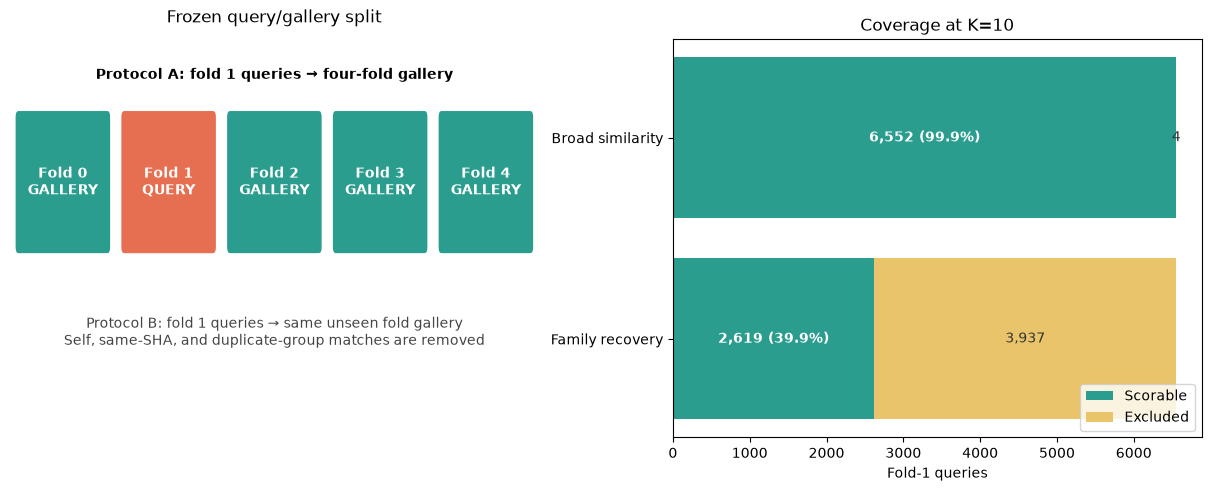

In [2]:
import os
from pathlib import Path

cache_root = Path("/tmp/mla2-task4-cache")
matplotlib_cache = cache_root / "matplotlib"
xdg_cache = cache_root / "xdg"
matplotlib_cache.mkdir(parents=True, exist_ok=True)
xdg_cache.mkdir(parents=True, exist_ok=True)
os.environ["MPLCONFIGDIR"] = str(matplotlib_cache)
os.environ["XDG_CACHE_HOME"] = str(xdg_cache)

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from IPython.display import display

coverage_k10 = protocol_coverage.loc[protocol_coverage["k"].eq(10)].copy()
coverage_k10["protocol"] = coverage_k10["protocol"].map(
    {"primary": "Protocol A: broad similarity", "family": "Protocol B: family recovery"}
)
coverage_k10["coverage_pct"] = (
    100 * coverage_k10["scored_queries"] / coverage_k10["total_queries"]
)
coverage_summary = coverage_k10.rename(
    columns={
        "protocol": "Evaluation",
        "total_queries": "Queries",
        "scored_queries": "Scorable",
        "excluded_queries": "Excluded",
        "coverage_pct": "Coverage",
    }
)[["Evaluation", "Queries", "Scorable", "Excluded", "Coverage"]]
display(coverage_summary.style.hide(axis="index").format({"Coverage": "{:.1f}%"}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)

fold_ax = axes[0]
fold_ax.set_xlim(0, 5)
fold_ax.set_ylim(0, 2.2)
fold_ax.axis("off")
for position, fold in enumerate(range(5)):
    is_query = fold == 1
    box = FancyBboxPatch(
        (position + 0.08, 1.05),
        0.84,
        0.72,
        boxstyle="round,pad=0.04",
        facecolor="#E76F51" if is_query else "#2A9D8F",
        edgecolor="white",
        linewidth=2,
    )
    fold_ax.add_patch(box)
    role = "QUERY" if is_query else "GALLERY"
    fold_ax.text(
        position + 0.5,
        1.41,
        f"Fold {fold}\n{role}",
        ha="center",
        va="center",
        color="white",
        weight="bold",
    )
fold_ax.text(2.5, 1.98, "Protocol A: fold 1 queries → four-fold gallery", ha="center", weight="bold")
fold_ax.text(
    2.5,
    0.58,
    "Protocol B: fold 1 queries → same unseen fold gallery\n"
    "Self, same-SHA, and duplicate-group matches are removed",
    ha="center",
    va="center",
    color="#444444",
)
fold_ax.set_title("Frozen query/gallery split", pad=12)

bar_ax = axes[1]
labels = ["Broad similarity", "Family recovery"]
scorable = coverage_k10["scored_queries"].to_numpy()
excluded = coverage_k10["excluded_queries"].to_numpy()
y_positions = range(len(labels))
bar_ax.barh(y_positions, scorable, color="#2A9D8F", label="Scorable")
bar_ax.barh(y_positions, excluded, left=scorable, color="#E9C46A", label="Excluded")
bar_ax.set_yticks(list(y_positions), labels)
bar_ax.invert_yaxis()
bar_ax.set_xlabel("Fold-1 queries")
bar_ax.set_title("Coverage at K=10")
bar_ax.legend(loc="lower right")
for row, (usable, omitted) in enumerate(zip(scorable, excluded, strict=True)):
    percentage = 100 * usable / (usable + omitted)
    bar_ax.text(
        usable / 2,
        row,
        f"{usable:,} ({percentage:.1f}%)",
        ha="center",
        va="center",
        color="white",
        weight="bold",
    )
    if omitted:
        bar_ax.text(
            usable + omitted / 2,
            row,
            f"{omitted:,}",
            ha="center",
            va="center",
            color="#333333",
        )

figure_path = ROOT / "results/figures/task4/retrieval_protocol_overview.png"
fig.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()

**What this proves**

- Protocol A can score 6,552 of 6,556 fold-1 queries (99.9%).
- Protocol B can score 2,619 queries (39.9%) after trivial exact matches are removed.
- Excluded queries have no possible positive result, so they are reported but not scored as model failures.
- This validates the evaluation setup only. Model quality remains unknown until the baseline and learned search methods are run.

## 3. Development-validation strategy

**CV mode: fixed fold `1` for ordinary candidate comparison.**

Train on development folds `0`, `2`, `3`, and `4`; use fold `1` as unseen
validation. The fold never rotates between epochs. This gives every candidate the
same affordable comparison.

After the comparison, rerun only the top two configurations by Protocol A mean
nDCG@10 from scratch with each development fold held out in turn. Report the
unweighted mean and standard deviation across all five fresh runs; never report
only the best-looking fold.


## 4. Fixed-fold declaration

**Validation fold: `1`.**

The repository seed is `2753`. The recorded draw
`random.Random(2753).choice(range(5))` selected fold `1`. This value is frozen and
is not redrawn at runtime.


## 5. Task-specific preprocessing and leakage rules

**Frozen input contract: `240×320` (width × height) RGB.**

- Inputs available at prediction time: any Pillow-decodable teacher, V1, or user image.
- Task transform pipeline: EXIF correction → white alpha compositing → RGB → aspect-preserving LANCZOS resize → centred white letterbox.
- Padding rule: return a content mask; exclude padding from fitted values and suitable fixed features. After learned normalization, padding is neutral zero.
- Pixel rule: cache losslessly as `uint8`, then scale to `[0, 1]` at model input.
- Values learned from data: per-source RGB mean and standard deviation for learned models only.
- Fit boundary: training folds only for the current round. Fold `1` uses folds `0`, `2`, `3`, and `4`.
- Validation and user-query rule: transform with the model's saved training-source values; never refit or pick values from an incoming query.
- Holdout rule: sealed until Notebook 06 after every choice is frozen.

Decision 0021 chooses the larger input to preserve fine V1 detail for learned models. This is an explicit policy override: the fixed probe winner remained `96×128`, and `240×320` ranked third on its equal-source score. The selected-size local caches contain the same 32,773 development IDs for teacher and V1. They contain no holdout, quarantine, or official prediction pixels.


## 6. Preprocessing comparison and decision

A fixed, untrained `4×4` spatial HSV-and-edge probe compared three sizes. Colour and edge blocks had equal weight. Exact cosine ranking used the frozen protocols and every eligible fold-1 query.

| Comparison | Alternatives | Controlled variables | Decision evidence |
|---|---|---|---|
| Input size | `60×80`, `96×128`, `240×320` | Probe, IDs, folds, metrics, colour, padding | Same-source nDCG@10 ranks the probe; decision 0021 adds the learned-detail policy and cost |
| Image source direction | Teacher → teacher, V1 → V1, Teacher → V1, V1 → teacher | Size and ranking rules | Same-source directions rank the probe; cross-source directions test robustness |
| Arbitrary shape | Clean, wide canvas, tall canvas | Frozen `240×320` size, query IDs, gallery | nDCG@10 change and Top-10 overlap |

The fixed probe winner remained **`96×128`**. Its fold-1 equal-source score was `0.49248`, versus `0.49199` for `60×80` and `0.48988` for `240×320`. Across five held-out folds, `96×128` remained slightly ahead of `60×80`, but the gain was smaller than fold variation.

Decision 0021 nevertheless freezes **`240×320`** to preserve fine V1 information for learned models. This is not a claim that it won the probe. It uses 6.25 times the pixels of `96×128`; teacher upsampling adds no real detail, and later learned-model evidence must justify the extra cost.

The wide and tall tests remain a serious limitation: deterministic letterboxing does not make a small clothing region robust to a large canvas. Later model analysis and the app must treat large backgrounds as a known failure.

Evidence: `preprocessing_size_selection.csv`, `preprocessing_stability.csv`, `preprocessing_robustness.csv`, and `preprocessing_comparison.png` under the Task 4 results folders. This fixed probe supports a transparent trade-off; it **does not prove learned-model quality**.


scope,selection_rank,size,width,height,pixels,teacher_ndcg_at_10,v1_ndcg_at_10,selection_ndcg_at_10,mean_selection_ndcg_at_10,std_selection_ndcg_at_10
development,1,96x128,96,128,12288,0.49410,0.49086,0.49248,0.49287,0.00279
development,2,60x80,60,80,4800,0.49294,0.49104,0.49199,0.49245,0.00265
development,3,240x320,240,320,76800,0.49521,0.48454,0.48988,nan,nan


scope,source,query_variant,queries,ndcg_at_10,ndcg_change_from_clean,mean_top10_overlap
development,teacher,clean,6556,0.49521,+0.00000,1.000
development,teacher,wide,6556,0.11059,-0.38462,0.041
development,teacher,tall,6556,0.16514,-0.33007,0.079
development,v1,clean,6556,0.48454,+0.00000,1.000
development,v1,wide,6556,0.10979,-0.37475,0.036
development,v1,tall,6556,0.17260,-0.31195,0.082


size,pixels,images_per_second,float32_rgb_kib_per_image
60x80,4800,101.3,56.2
96x128,12288,49.1,144.0
240x320,76800,42.5,900.0


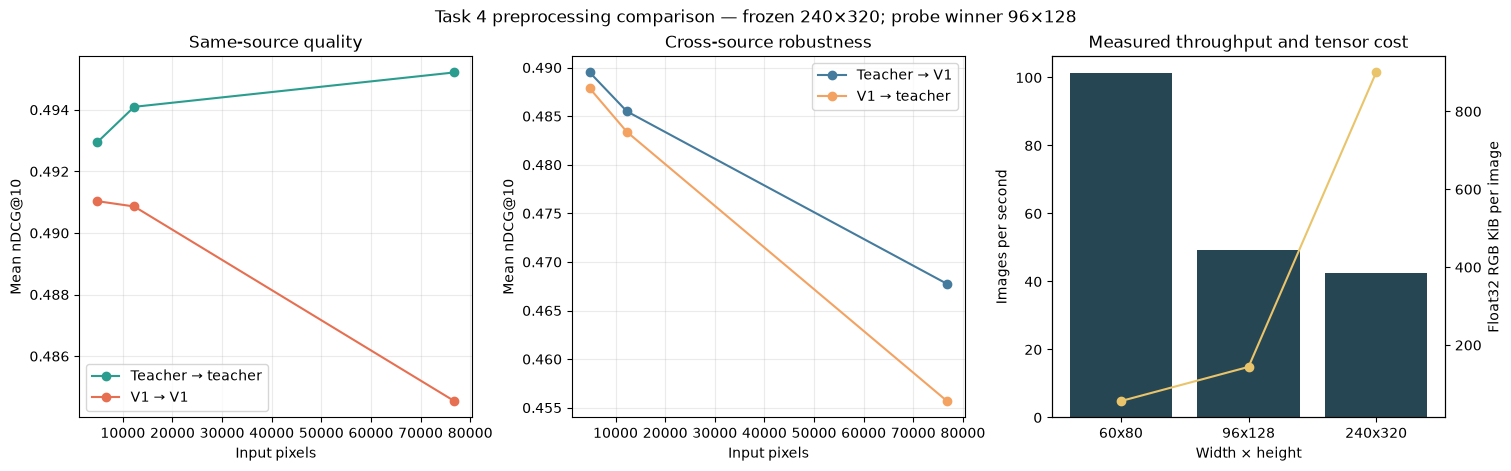

In [3]:
import pandas as pd

preprocessing_comparison = pd.read_csv(
    ROOT / "results/evidence/task4/preprocessing_comparison.csv"
)
preprocessing_selection = pd.read_csv(
    ROOT / "results/evidence/task4/preprocessing_size_selection.csv"
)
preprocessing_stability = pd.read_csv(
    ROOT / "results/evidence/task4/preprocessing_stability.csv"
)
preprocessing_robustness = pd.read_csv(
    ROOT / "results/evidence/task4/preprocessing_robustness.csv"
)

stability_summary = preprocessing_stability[
    ["size", "mean_selection_ndcg_at_10", "std_selection_ndcg_at_10"]
].drop_duplicates()
selection_summary = preprocessing_selection.merge(stability_summary, on="size", how="left")
display(
    selection_summary.style.hide(axis="index").format(
        {
            "teacher_ndcg_at_10": "{:.5f}",
            "v1_ndcg_at_10": "{:.5f}",
            "selection_ndcg_at_10": "{:.5f}",
            "mean_selection_ndcg_at_10": "{:.5f}",
            "std_selection_ndcg_at_10": "{:.5f}",
        }
    )
)
display(
    preprocessing_robustness.style.hide(axis="index").format(
        {
            "ndcg_at_10": "{:.5f}",
            "ndcg_change_from_clean": "{:+.5f}",
            "mean_top10_overlap": "{:.3f}",
        }
    )
)

fold1_ndcg = preprocessing_comparison.loc[
    preprocessing_comparison["fold"].eq(1)
    & preprocessing_comparison["protocol"].eq("primary")
    & preprocessing_comparison["metric"].eq("ndcg")
    & preprocessing_comparison["k"].eq(10)
    & preprocessing_comparison["aggregation"].eq("query_mean")
].copy()
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), constrained_layout=True)
for source, label, colour in (
    ("teacher", "Teacher → teacher", "#2A9D8F"),
    ("v1", "V1 → V1", "#E76F51"),
):
    rows = fold1_ndcg.loc[
        fold1_ndcg["query_source"].eq(source)
        & fold1_ndcg["gallery_source"].eq(source)
    ].sort_values("width")
    axes[0].plot(rows["width"] * rows["height"], rows["value"], marker="o", label=label, color=colour)
axes[0].set(xlabel="Input pixels", ylabel="Mean nDCG@10", title="Same-source quality")
axes[0].legend()
axes[0].grid(alpha=0.25)

for query_source, gallery_source, label, colour in (
    ("teacher", "v1", "Teacher → V1", "#457B9D"),
    ("v1", "teacher", "V1 → teacher", "#F4A261"),
):
    rows = fold1_ndcg.loc[
        fold1_ndcg["query_source"].eq(query_source)
        & fold1_ndcg["gallery_source"].eq(gallery_source)
    ].sort_values("width")
    axes[1].plot(rows["width"] * rows["height"], rows["value"], marker="o", label=label, color=colour)
axes[1].set(xlabel="Input pixels", ylabel="Mean nDCG@10", title="Cross-source robustness")
axes[1].legend()
axes[1].grid(alpha=0.25)

ordered_cost = preprocessing_selection.sort_values("pixels").copy()
extraction_seconds = (
    fold1_ndcg[["size", "query_source", "query_transform_seconds"]]
    .drop_duplicates()
    .groupby("size", sort=False)["query_transform_seconds"]
    .sum()
)
development_images = int(splits["partition"].eq("development").sum())
ordered_cost["images_per_second"] = (
    2 * development_images / ordered_cost["size"].map(extraction_seconds)
)
ordered_cost["float32_rgb_kib_per_image"] = (
    ordered_cost["width"] * ordered_cost["height"] * 3 * 4 / 1024
)
display(
    ordered_cost[
        ["size", "pixels", "images_per_second", "float32_rgb_kib_per_image"]
    ].style.hide(axis="index").format(
        {
            "images_per_second": "{:.1f}",
            "float32_rgb_kib_per_image": "{:.1f}",
        }
    )
)
axes[2].bar(ordered_cost["size"], ordered_cost["images_per_second"], color="#264653")
axes[2].set(
    xlabel="Width × height",
    ylabel="Images per second",
    title="Measured throughput and tensor cost",
)
tensor_axis = axes[2].twinx()
tensor_axis.plot(
    ordered_cost["size"],
    ordered_cost["float32_rgb_kib_per_image"],
    color="#E9C46A",
    marker="o",
)
tensor_axis.set_ylabel("Float32 RGB KiB per image")
fig.suptitle("Task 4 preprocessing comparison — frozen 240×320; probe winner 96×128")
figure_path = ROOT / "results/figures/task4/preprocessing_comparison.png"
fig.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()

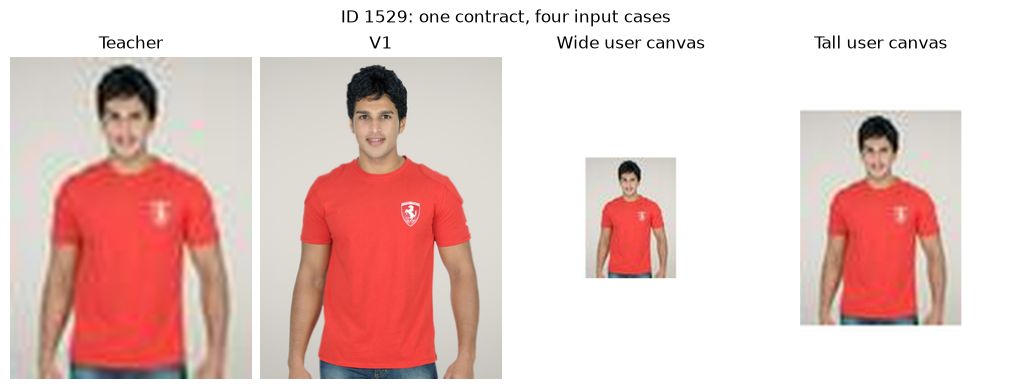

In [4]:
from PIL import Image

from fashion.task4.preprocessing import PreprocessingContract, preprocess_image
from fashion.task4.preprocessing_experiment import build_odd_aspect_canvas

variant_index = pd.read_csv(
    ROOT / "data/processed/task4/external_variant_index.csv.gz",
    keep_default_na=False,
)
example_id = int(primary_views.queries["id"].min())
example = variant_index.loc[variant_index["id"].eq(example_id)].iloc[0]
with Image.open(ROOT / example["teacher_path"]) as image:
    teacher_image = image.copy()
with Image.open(ROOT / example["external_path"]) as image:
    v1_image = image.copy()

contract = PreprocessingContract(width=240, height=320)
example_images = [
    ("Teacher", preprocess_image(teacher_image, contract).pixels),
    ("V1", preprocess_image(v1_image, contract).pixels),
    (
        "Wide user canvas",
        preprocess_image(build_odd_aspect_canvas(teacher_image, "wide"), contract).pixels,
    ),
    (
        "Tall user canvas",
        preprocess_image(build_odd_aspect_canvas(teacher_image, "tall"), contract).pixels,
    ),
]
fig, axes = plt.subplots(1, 4, figsize=(10, 4), constrained_layout=True)
for axis, (title, pixels) in zip(axes, example_images, strict=True):
    axis.imshow(pixels)
    axis.set_title(title)
    axis.axis("off")
fig.suptitle(f"ID {example_id}: one contract, four input cases")
plt.show()

**What this proves**

- The fixed probe winner remained `96×128`; `240×320` ranked third overall despite the strongest teacher→teacher score.
- Decision 0021 openly trades probe score and 6.25× more pixels for preserving fine V1 detail for learned models.
- Teacher and V1 can use one deterministic `240×320` contract with fold-safe learned normalization.

**What this does not prove**

- The fixed probe does not prove that a learned model will benefit from the extra V1 detail or justify its cost.
- Teacher `60×80` upsampling cannot create new detail.
- Letterboxing preserves shape, but the wide/tall failure shows that it does not locate small clothing inside a large background.
- The holdout remains sealed; no final-system claim is made here.

## 7. Hypotheses and baseline

The frozen baseline is the untrained `spatial-hsv-edge-4x4-v2` descriptor at the accepted `240×320` RGB/LANCZOS letterbox input. Its 400 features use equal normalized HSV and edge blocks on a `4×4` grid. Exact cosine distance ranks products, and minimum-distance product fusion keeps only the best image-variant distance for each product before Top-K. Nothing was tuned for this run, it has no checkpoint, and it creates no `results/runs.csv` row.

Quality uses fixed development fold `1`, Protocol A mean per-query linear nDCG@10, and all four source directions. The fresh one-thread reproduction uses `chunk_size=256` and named absolute tolerance `1e-5`. Default-thread V1 → teacher exactly matched stored preprocessing evidence. Forced one-thread near-tie ranking drift was at most `9.709e-6`.

- **Hypothesis 1 — PASS:** the same-source mean (`0.48987767`) beats the seeded random floor (`0.06235565`) by `0.42752202`.
- **Hypothesis 2 — FAIL:** cross-source quality must be at least 95% of same-source quality. The measured cross-source mean is `0.46171089`, and the ratio is `0.94250242`. This is below `0.95`, so we **reject** the source-robustness hypothesis.

A baseline is a comparison anchor, not a preselected winner. Learned models, the deployed source, and the final winner remain open. The labelled holdout remains sealed.


In [5]:
import json

baseline_evidence_dir = ROOT / "results/evidence/task4"
baseline_summary = pd.read_csv(baseline_evidence_dir / "baseline_summary.csv")
baseline_query_metrics = pd.read_csv(
    baseline_evidence_dir / "baseline_query_metrics.csv"
)
baseline_failure_slices = pd.read_csv(
    baseline_evidence_dir / "baseline_failure_slices.csv"
)
baseline_timing = pd.read_csv(baseline_evidence_dir / "baseline_timing.csv")
baseline_examples = pd.read_csv(baseline_evidence_dir / "baseline_examples.csv")
baseline_cost = json.loads(
    (baseline_evidence_dir / "baseline_cost.json").read_text(encoding="utf-8")
)

direction_labels = {
    ("teacher", "teacher"): "Teacher → teacher",
    ("v1", "v1"): "V1 → V1",
    ("teacher", "v1"): "Teacher → V1",
    ("v1", "teacher"): "V1 → teacher",
}
baseline_k10 = baseline_summary.loc[
    baseline_summary["method"].eq("spatial-hsv-edge-4x4-v2")
    & baseline_summary["protocol"].eq("primary")
    & baseline_summary["metric"].eq("ndcg")
    & baseline_summary["k"].eq(10)
    & baseline_summary["aggregation"].eq("query_mean"),
    ["query_source", "gallery_source", "value"],
].copy()
baseline_k10["Direction"] = [
    direction_labels[(query_source, gallery_source)]
    for query_source, gallery_source in baseline_k10[
        ["query_source", "gallery_source"]
    ].itertuples(index=False, name=None)
]
baseline_k10["nDCG@10"] = baseline_k10["value"].map(lambda value: f"{value:.8f}")
display(baseline_k10[["Direction", "nDCG@10"]].reset_index(drop=True))

,Direction,nDCG@10
0,Teacher → teacher,0.49521342
1,Teacher → V1,0.46774604
2,V1 → teacher,0.45567575
3,V1 → V1,0.48454193


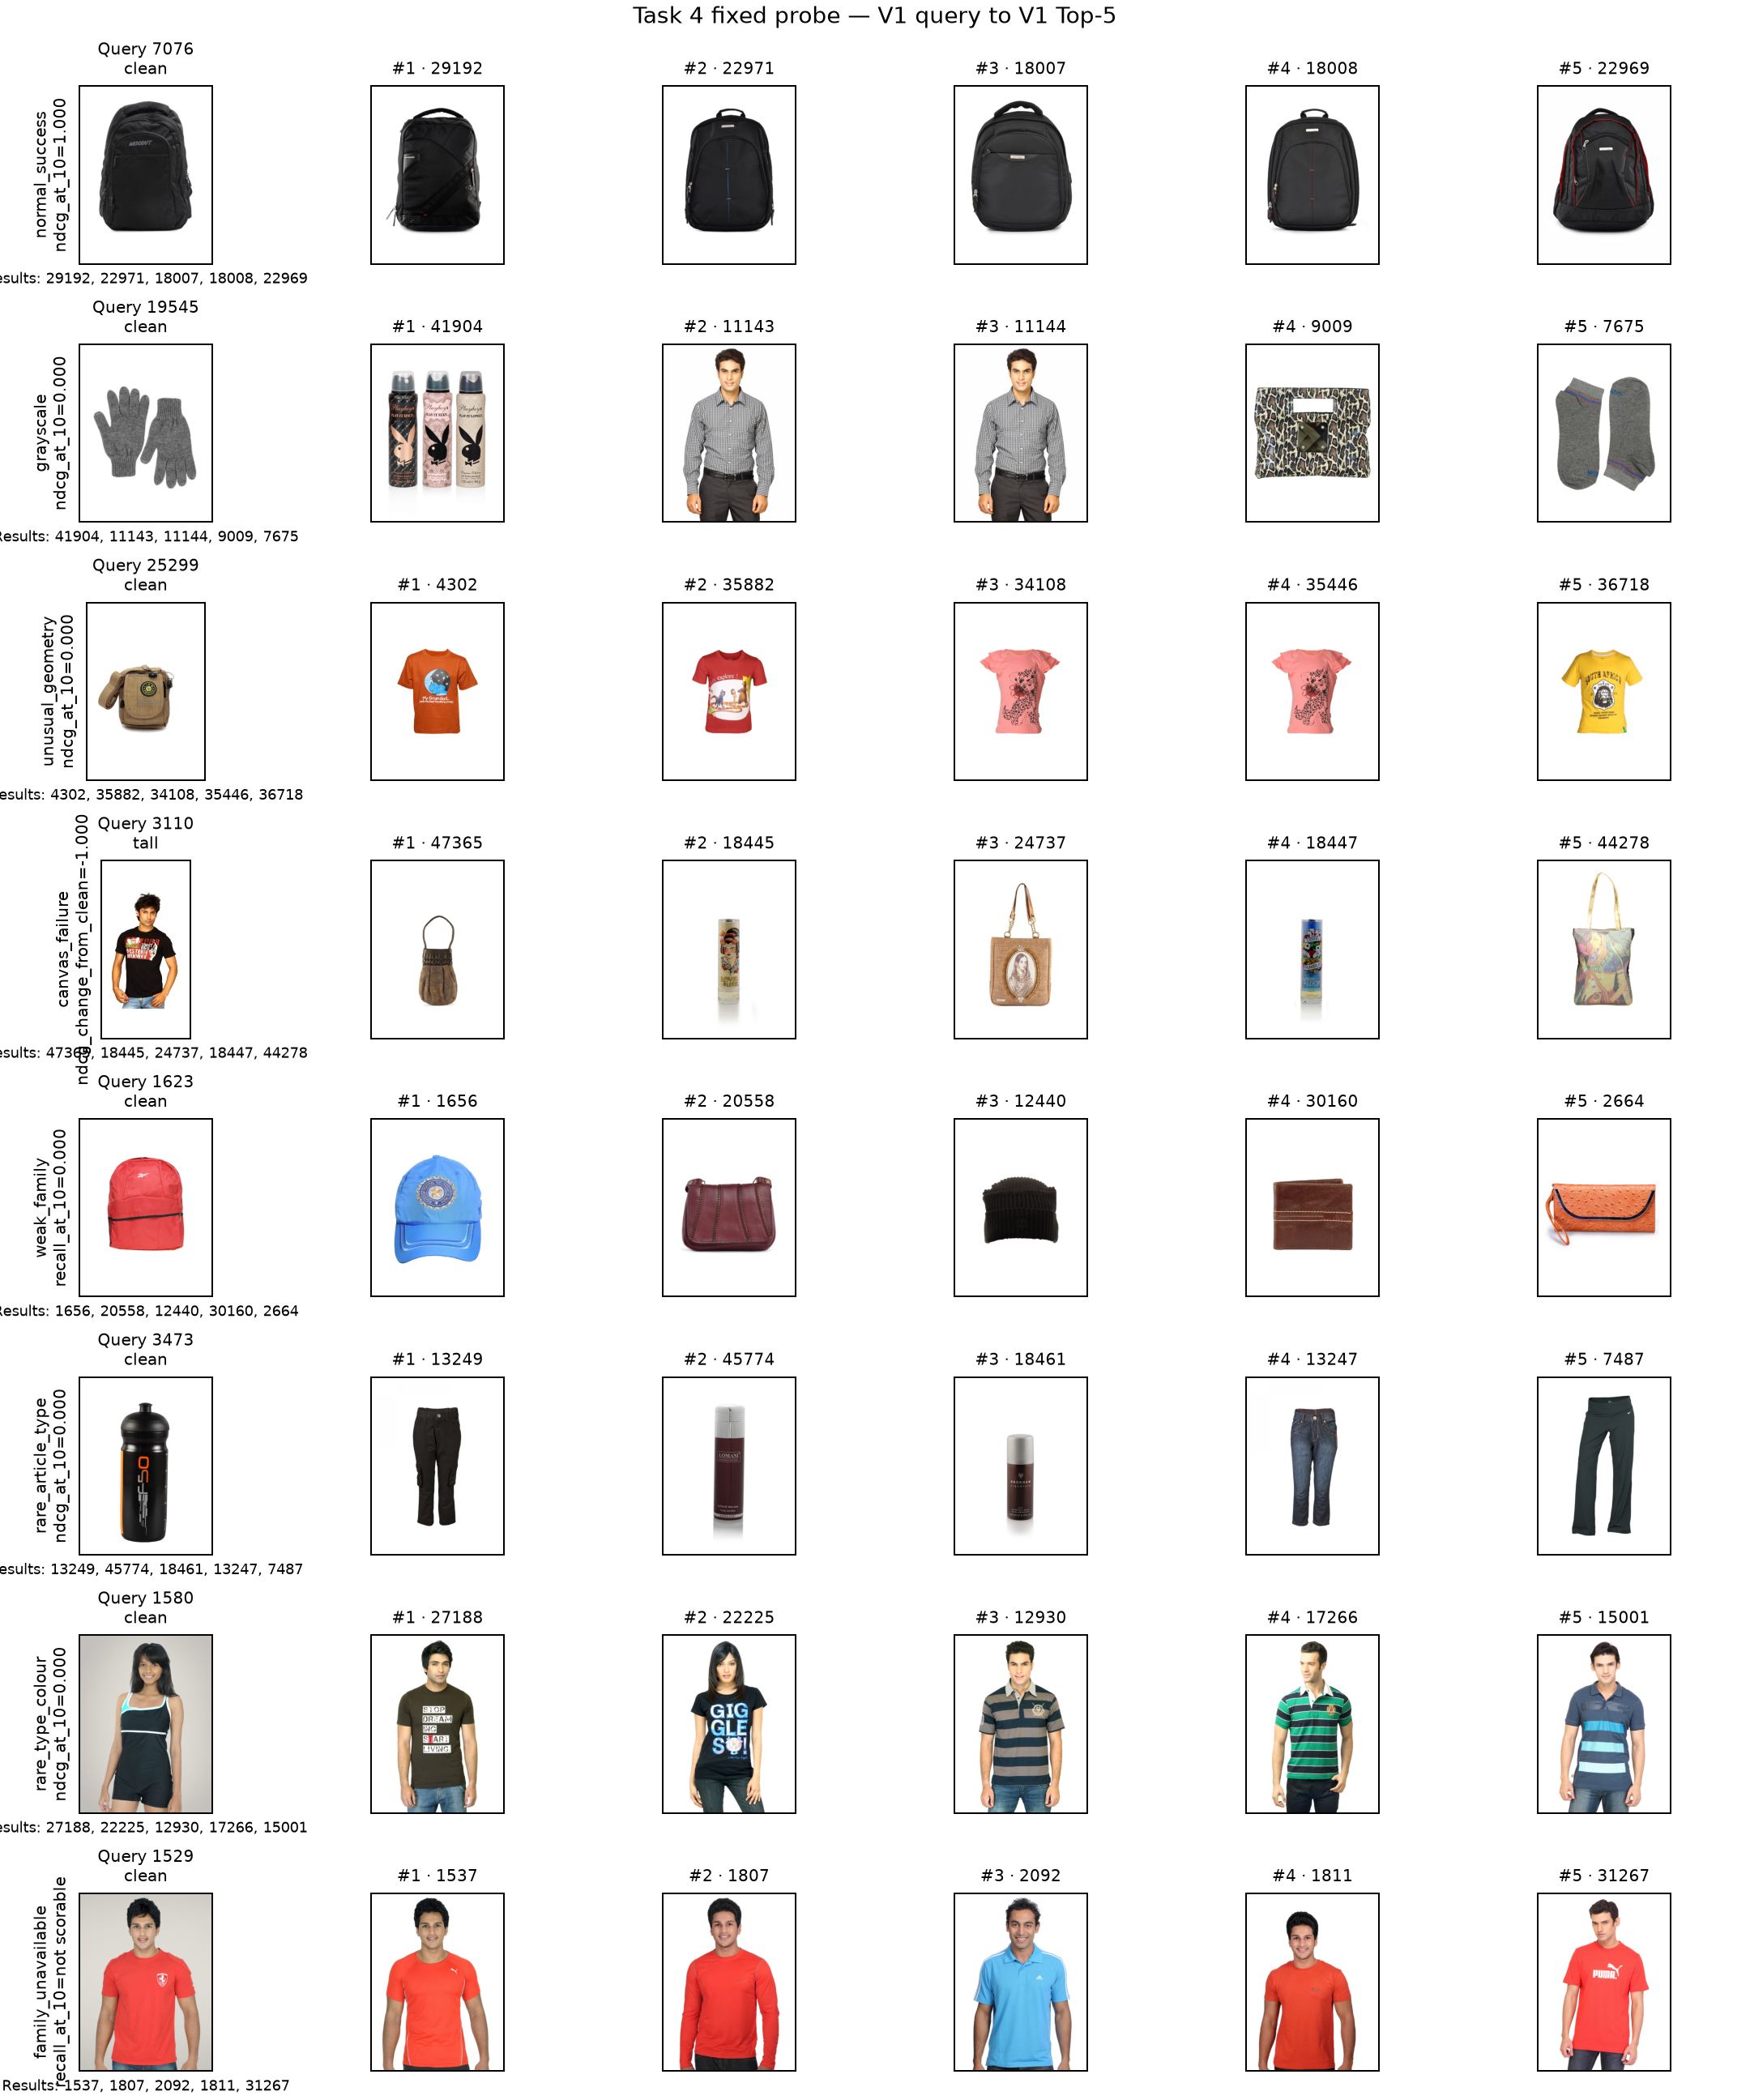

In [6]:
from IPython.display import Image as NotebookImage

baseline_figure_path = ROOT / "results/figures/task4/baseline_examples.png"
display(NotebookImage(filename=str(baseline_figure_path)))

## 8. Candidate model comparisons

Define candidate families only after checking the assignment constraints.

| Candidate ID | Why include it | Capacity/complexity control | Scratch-training compliance | Expected trade-off |
|---|---|---|---|---|
| TODO(owner) | TODO(owner) | TODO(owner) | TODO(owner) | TODO(owner) |

No candidate is selected in advance.


## 9. Metric selection and freeze

- Primary ranking-quality metric: mean per-query linear nDCG@10
- Cutoffs: K values `5`, `10`, and `20` for Protocol A; K=`10` for Protocol B
- Undefined-query rule: exclude only when ideal DCG is zero or no eligible family positive remains; report coverage and never replace undefined values with zero
- Deterministic tie-break: ascending distance, then ascending numeric product ID
- Secondary Protocol A measures: broad Precision@K, strict Precision@K, and tie rate
- Supporting Protocol B measures: Recall@10, Hit Rate@10, Precision@10, coverage, and tie rate
- Aggregation: the Protocol A query mean selects the winner; the `articleType` class macro is supporting evidence
- Stability aggregation: unweighted mean and standard deviation across five fresh runs for the top two configurations
- Frozen by: accepted decision `0019-task4-retrieval-evaluation.md`, 2026-08-26

Linear gain makes a grade-2 result worth twice a grade-1 result. Protocol B stays
supporting evidence and does not enter a custom combined winner score.


## 10. Experiment matrix

| Run intent | CV mode/fold | Preprocessing ID | Candidate ID | Controlled seed/budget | Question answered |
|---|---|---|---|---|---|
| TODO(owner) | TODO(owner) | TODO(owner) | TODO(owner) | TODO(owner) | TODO(owner) |

Keep the matrix broad enough to justify choices, but small enough that each run
receives error and cost analysis.


## 11. Run registry

Every training/evaluation run must append through `fashion.train.registry` to
`results/runs.csv`.

- Run IDs: TODO(owner after execution)
- Checkpoint paths: TODO(owner after execution)
- Configuration hashes: TODO(owner after execution)
- Evidence tables/figures linked to run IDs: TODO(owner after execution)

Do not hand-type final comparison numbers into the report.


## 12. Error analysis

The predeclared development slices in `baseline_failure_slices.csv` contain 44 grayscale queries, 40 rare-`articleType` queries (1–9 positives), 833 rare `articleType`-`baseColour` queries (fewer than 10 strict positives), 2 unusual-geometry queries, 3,937 family-unavailable queries (zero family positives), and 1,659 weak-family queries (1–4 positives).

`baseline_examples.csv` and `baseline_examples.png` preserve all eight reviewed rows: a normal success plus grayscale, unusual-geometry, tall-canvas, weak-family, rare-type, rare-type-colour, and family-unavailable cases. The canvas example fell from nDCG@10 `1.0` when clean to a change of `-1.0` when placed on a tall white canvas. The rare and grayscale examples also reach zero, while family-unavailable Recall@10 is undefined rather than silently changed to zero.

These cases show different limits. Metadata relevance is only a proxy for visual similarity. V1 is not independent data. Sparse classes and product families limit what the gallery can recover. Large backgrounds can dominate the fixed descriptor even though letterboxing is deterministic. These failures remain visible for learned-model comparisons.


## 13. Robustness and efficiency

The tracked `baseline_cost.json` and `baseline_timing.csv` measure CPU, one thread, batch size one, 100 warm-ups, and every 6,556 query once in each direction. End-to-end p50 / p95 seconds are:

- Teacher → teacher: `0.0844252695` / `0.08591582875`
- V1 → V1: `0.1314013365` / `0.1409705065`
- Teacher → V1: `0.0848337965` / `0.08672196125`
- V1 → teacher: `0.131808274` / `0.141162569`

Teacher and V1 indexes are each 26,217 × 400 and `42,156,936` bytes. Their measured build times are `430.862066` and `1648.505369` seconds. Peak child-process RSS is `1,038,663,680` bytes for each build. These timing, build, and RSS values are machine-dependent.

- p95 end-to-end latency < 1 second: PASS
- index size < 1 GiB: PASS

Large canvases remain a known failure. V1 → V1 mean nDCG@10 falls from `0.48454193` clean to `0.10979303` wide and `0.17259584` tall. Learned systems must repeat the same quality, p50/p95, index, memory, and canvas checks; their practical verdicts remain open.


## 14. Decision log

| Decision | Evidence considered | Choice | Rejected alternatives | Limitation | Date/owner |
|---|---|---|---|---|---|
| Retrieval evaluation contract | Approved design, split boundary, protocol tests, and coverage evidence | Fixed fold `1`; Protocol A mean linear nDCG@10; Protocol B Recall@10 support | rotating validation folds; a combined A/B score; undefined-as-zero | metadata relevance is a proxy; V1 is not independent data | 2026-08-26 / decision 0019 |
| Task 4 image preprocessing | Three sizes, four source directions, top-two five-fold stability, synthetic wide/tall queries, detail policy, and cost | `240×320` RGB; EXIF-correct aspect-preserving LANCZOS resize; centred white letterbox and content mask | probe-ranked `96×128`; `60×80`; stretching or cropping | fixed probe ranked `240×320` third; 6.25× pixel cost; teacher upsampling adds no detail | 2026-08-27 / decision 0021 |
| Untrained baseline search | Four source directions, random floor, source-ratio hypothesis, slice/canvas failures, CPU timing, and index cost | `spatial-hsv-edge-4x4-v2`; minimum-distance product fusion; same-source anchor | treating cross-source robustness as passed; hiding undefined family scores | 95% source hypothesis rejected; large backgrounds fail; timing is machine-dependent | 2026-08-28 / decision 0022 |
| Learned model, fusion, index, and final winner | TODO(owner) | TODO(owner) | TODO(owner) | TODO(owner) | TODO(owner) |

Record later choices as they are made. Do not rewrite history after holdout access.


## 15. Handoff to final evaluation

Before Notebook 06, provide:

- frozen winning run ID(s): TODO(owner)
- frozen preprocessing configuration: `240×320` RGB; EXIF-correct aspect-preserving LANCZOS resize; centred white letterbox; saved training-fold source mean/std for learned models
- frozen metric definition: Protocol A mean per-query linear nDCG@10, with Protocol B Recall@10 as supporting evidence
- preprocessing-size fixed-fold and probe top-two five-fold evidence: complete; decision 0021 records the explicit `240×320` detail override; learned-model top-two stability evidence remains TODO(owner after runs)
- refit procedure for all development: TODO(owner)
- expected final checkpoint/output path: TODO(owner)
- unresolved risks: metadata relevance is not human ground truth; V1 is not independent data; large query backgrounds hurt the fixed probe; add model-specific limits after evidence

Notebook 06 alone may unlock the labelled holdout after every remaining choice is
frozen. Refit on all development data, evaluate holdout once, and make no model or
protocol changes after seeing it.

**Handoff status: NOT READY — the learned model, runs, index, and final winner remain open.**
